In [1]:
!pip install pandas numpy matplotlib tensorflow scikit-learn wandb nbformat

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Deep Learning libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.metrics import Precision, Recall

# Final evaluation metrics (accuracy/precision/recall/f1), computed the same way as the logreg notebook
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Shared data prep (download + label + balance + split) - identical for every model
from data_prep import load_review_data

# Experiment tracking (run `pip install wandb` first; in Colab: !pip install wandb)
import wandb
from wandb.integration.keras import WandbMetricsLogger

print(f"TensorFlow Version: {tf.__version__}")

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU support: ENABLED ({len(gpus)} device(s) found)")
    for gpu in gpus:
        print(f"  {gpu}")
else:
    print("GPU support: DISABLED (running on CPU)")

I0000 00:00:1783356506.960490   96743 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow Version: 2.21.0
GPU support: ENABLED (1 device(s) found)
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
# Load the shared, balanced, split dataset (same data the logistic-regression notebook uses)
data = load_review_data()

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
counts  = data["counts"]

'All_Beauty.jsonl.gz' already exists, skipping download.
Parsing JSONL.GZ file...
Loaded 701,528 records.

Dataset ready: 290,228 balanced reviews (145,114 per class); 56,307 neutral (3-star) dropped.
Train: 217,671 | Test: 72,557


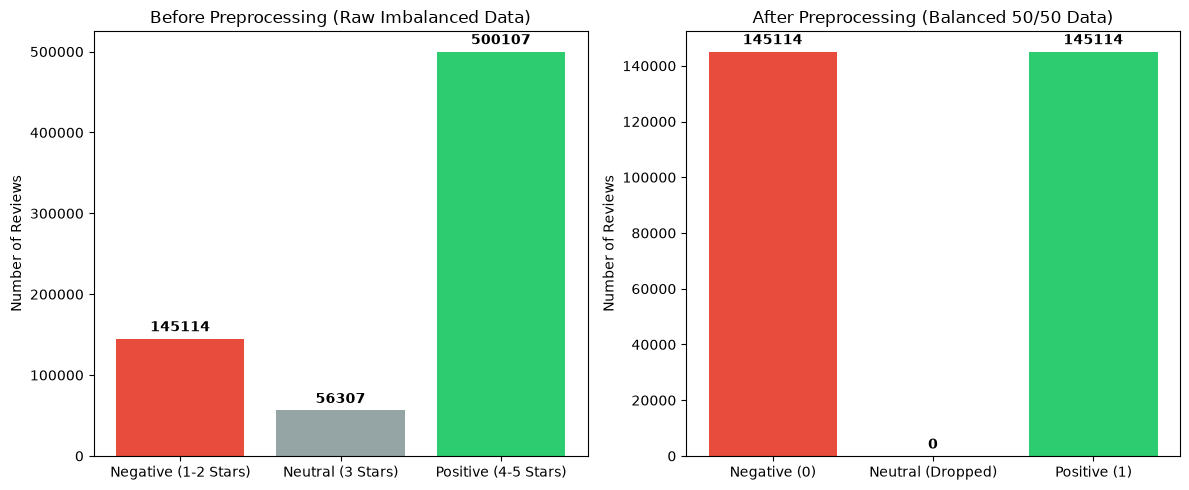

In [4]:
# Visualization of class distributions (uses the shared counts)
raw_neg = counts["raw_negative"]
raw_neu = counts["raw_neutral"]
raw_pos = counts["raw_positive"]

bal_neg = counts["balanced_per_class"]
bal_neu = 0  # 3-star reviews were dropped
bal_pos = counts["balanced_per_class"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

categories_before = ['Negative (1-2 Stars)', 'Neutral (3 Stars)', 'Positive (4-5 Stars)']
counts_before = [raw_neg, raw_neu, raw_pos]
axes[0].bar(categories_before, counts_before, color=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[0].set_title('Before Preprocessing (Raw Imbalanced Data)')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(counts_before):
    axes[0].text(i, v + (max(counts_before)*0.01), str(v), ha='center', va='bottom', fontweight='bold')

categories_after = ['Negative (0)', 'Neutral (Dropped)', 'Positive (1)']
counts_after = [bal_neg, bal_neu, bal_pos]
axes[1].bar(categories_after, counts_after, color=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[1].set_title('After Preprocessing (Balanced 50/50 Data)')
axes[1].set_ylabel('Number of Reviews')
for i, v in enumerate(counts_after):
    axes[1].text(i, v + (max(counts_after)*0.01), str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
# Model-specific preprocessing: turn text into padded integer sequences for the LSTM.
# (The logistic-regression notebook does its own, different vectorization here instead.)

vocab_size = 15000   # Number of unique words to keep
max_length = 120     # Max length of a review
trunc_type = 'post'  # Truncate long reviews at the end
padding_type = 'post'# Pad short reviews at the end
oov_tok = "<OOV>"    # Token for Out Of Vocabulary words

print("Fitting the tokenizer...")
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train)

# Convert text into padded sequences of numbers
train_sequences = tokenizer.texts_to_sequences(X_train)
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

test_sequences = tokenizer.texts_to_sequences(X_test)
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print(f"Training data shape: {train_padded.shape}")
print(f"Testing data shape: {test_padded.shape}")

Fitting the tokenizer...
Training data shape: (217671, 120)
Testing data shape: (72557, 120)


In [6]:
# Cell 5
embedding_dim = 64

model = Sequential([
    # Turns positive integers into dense vectors of fixed size
    Embedding(vocab_size, embedding_dim, input_length=max_length),

    # Bidirectional LSTM to capture contextual dependencies
    Bidirectional(LSTM(64, return_sequences=True)),

    # Condense the output to the most important features
    GlobalMaxPooling1D(),

    # Fully connected layers with Dropout to prevent overfitting
    Dense(64, activation='relu'),
    Dropout(0.5),

    # Output layer: Sigmoid returns a probability between 0 and 1
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

model.summary()

/home/benji/aiml/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1783356531.125602   96743 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5562 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:2b:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
num_epochs = 6
batch_size = 512

# Log in to Weights & Biases (prompts for your API key the first time;
# set WANDB_MODE=offline to skip uploading, or WANDB_MODE=disabled to turn it off)
wandb.login()

# Start a run and record the hyperparameters / dataset sizes for this experiment
run = wandb.init(
    entity="aiml2026",                    # the TEAM - without this, runs go to your personal workspace
    project="amazon-sentiment-analysis",  # shared project - teammates log their models here too
    group="neural-net",                 # this approach (logreg team uses group="logreg", etc.)
    job_type="train",
    name="bilstm-sentiment",
    tags=["bilstm"],
    config={
        "model": "Bidirectional LSTM",
        "vocab_size": vocab_size,
        "max_length": max_length,
        "embedding_dim": embedding_dim,
        "lstm_units": 64,
        "dropout": 0.5,
        "optimizer": "adam",
        "loss": "binary_crossentropy",
        "epochs": num_epochs,
        "batch_size": batch_size,
        "train_samples": len(X_train),
        "test_samples": len(X_test),
    },
)

# Early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

print("Starting model training...")
history = model.fit(
    train_padded, y_train,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_data=(test_padded, y_test),
    # WandbMetricsLogger streams per-epoch loss/accuracy/precision/recall to your W&B dashboard
    callbacks=[early_stopping, WandbMetricsLogger()]
)

# Final evaluation on the held-out test set: accuracy, precision, recall, f1-score
y_proba = model.predict(test_padded, verbose=0).ravel()
y_pred = (y_proba > 0.5).astype(int)

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print("\n--- MODEL PERFORMANCE (Test Set) ---")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

# Log the final summary metrics to W&B
wandb.log({
    "test_accuracy": test_accuracy,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1": test_f1,
})

# Close out the run so it is marked finished in the dashboard
wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/benji/.netrc.
wandb: Currently logged in as: hibenji to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Starting model training...
Epoch 1/3


I0000 00:00:1783356536.658992   96969 cuda_dnn.cc:461] Loaded cuDNN version 92400


426/426 ━━━━━━━━━━━━━━━━━━━━ 40s 85ms/step - accuracy: 0.9168 - loss: 0.2260 - precision: 0.9257 - recall: 0.9065 - val_accuracy: 0.9483 - val_loss: 0.1411 - val_precision: 0.9490 - val_recall: 0.9476
Epoch 2/3
426/426 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - accuracy: 0.9567 - loss: 0.1236 - precision: 0.9606 - recall: 0.9524 - val_accuracy: 0.9554 - val_loss: 0.1213 - val_precision: 0.9612 - val_recall: 0.9492
Epoch 3/3
426/426 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9644 - loss: 0.1023 - precision: 0.9680 - recall: 0.9606 - val_accuracy: 0.9574 - val_loss: 0.1172 - val_precision: 0.9658 - val_recall: 0.9485

--- MODEL PERFORMANCE (Test Set) ---
              precision    recall  f1-score   support

    Negative       0.95      0.97      0.96     36279
    Positive       0.97      0.95      0.96     36278

    accuracy                           0.96     72557
   macro avg       0.96      0.96      0.96     72557
weighted avg       0.96      0.96      0.96     72557



epoch/accuracy,▁▇█
epoch/epoch,▁▅█
epoch/learning_rate,▁▁▁
epoch/loss,█▂▁
epoch/precision,▁▇█
epoch/recall,▁▇█
epoch/val_accuracy,▁▆█
epoch/val_loss,█▂▁
epoch/val_precision,▁▆█
epoch/val_recall,▁█▅
+4,...


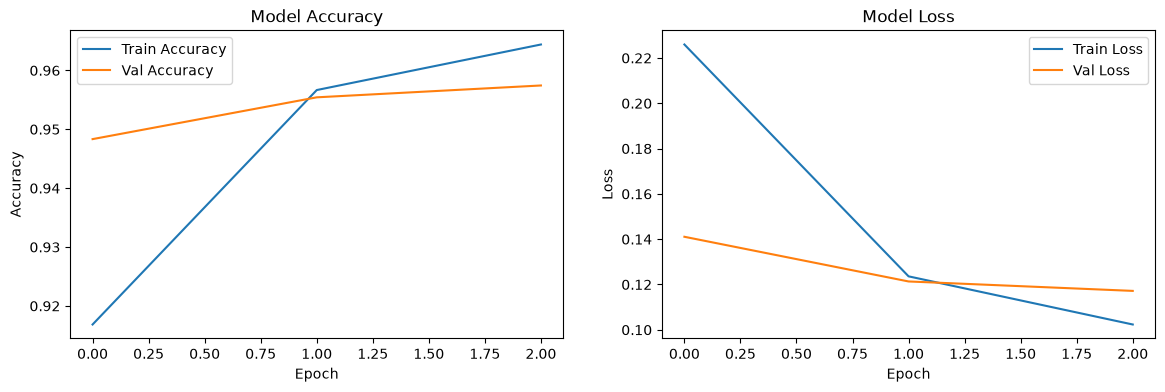

Review: 'These shoes look amazing and fit perfectly. Best purchase ever!'
Sentiment: Positive (Confidence Score: 0.9998)

Review: 'Terrible quality. The fabric ripped after one wash. Do not buy.'
Sentiment: Negative (Confidence Score: 0.0001)

Review: 'It's okay, but honestly a little overpriced for what you get.'
Sentiment: Negative (Confidence Score: 0.1063)



In [8]:
# Cell 7
# Plot Accuracy and Loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.show()

# --- Custom Review Tester ---
def predict_sentiment(review_text):
    # Process the raw text into the format the model expects
    seq = tokenizer.texts_to_sequences([review_text])
    padded = pad_sequences(seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)

    # Predict
    pred = model.predict(padded, verbose=0)[0][0]
    sentiment = "Positive" if pred > 0.5 else "Negative"

    print(f"Review: '{review_text}'")
    print(f"Sentiment: {sentiment} (Confidence Score: {pred:.4f})\n")

# Try it out with your own phrases!
predict_sentiment("These shoes look amazing and fit perfectly. Best purchase ever!")
predict_sentiment("Terrible quality. The fabric ripped after one wash. Do not buy.")
predict_sentiment("It's okay, but honestly a little overpriced for what you get.")